<a href="https://colab.research.google.com/github/shivvrai/Accident-detection/blob/main/RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading IMDB dataset...
Building improved Stacked SimpleRNN model...


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Compiling model...
Training model...
Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 40s 200ms/step - acc: 0.5971 - loss: 0.6531 - val_acc: 0.7566 - val_loss: 0.5071
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 91ms/step - acc: 0.7926 - loss: 0.4601 - val_acc: 0.8160 - val_loss: 0.4128
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 90ms/step - acc: 0.8399 - loss: 0.3764 - val_acc: 0.8300 - val_loss: 0.3900
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 132ms/step - acc: 0.8630 - loss: 0.3355 - val_acc: 0.7982 - val_loss: 0.4309
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 137ms/step - acc: 0.8854 - loss: 0.2834 - val_acc: 0.8136 - val_loss: 0.4121
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 33s 211ms/step - acc: 0.9035 - loss: 0.2421 - val_acc: 0.7200 - val_loss: 0.5461
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 154ms/step - acc: 0.9116 - loss: 0.2307 - val_acc: 0.8066 - val_loss: 0.4713
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 27s 173ms/step - acc: 0.9367 - loss: 0.1675 - val_acc: 0.8000 - val_loss: 0.53

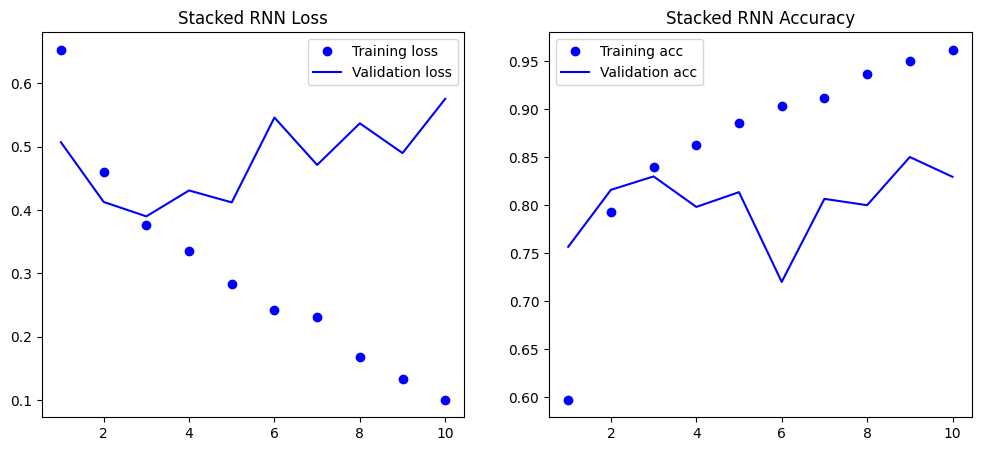

In [3]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout, SpatialDropout1D
import matplotlib.pyplot as plt

# 1. Load the IMDB dataset
print("Loading IMDB dataset...")
max_features = 10000
maxlen = 500

(input_train, y_train), (input_test, y_test) = imdb.load_data(num_words=max_features)

# 2. Preprocess the data (Padding sequences)
input_train = sequence.pad_sequences(input_train, maxlen=maxlen)
input_test = sequence.pad_sequences(input_test, maxlen=maxlen)

# 3. Build a 'Better' SimpleRNN model (Stacked RNN)
print("Building improved Stacked SimpleRNN model...")
model = Sequential()
model.add(Embedding(max_features, 64))
model.add(SpatialDropout1D(0.2))

# Adding multiple SimpleRNN layers (Stacked RNN)
# return_sequences=True is required when the next layer is also an RNN
model.add(SimpleRNN(64, return_sequences=True, dropout=0.2))
model.add(SimpleRNN(32, dropout=0.2))

model.add(Dense(1, activation='sigmoid'))

model.summary()

# 4. Compile the model
print("Compiling model...")
model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['acc'])

# 5. Train the model
print("Training model...")
history = model.fit(input_train, y_train,
                    epochs=10,
                    batch_size=128,
                    validation_split=0.2)

# 6. Evaluate the model
print("Evaluating model...")
loss, accuracy = model.evaluate(input_test, y_test, verbose=0)
print(f'Stacked RNN Test Loss: {loss:.4f}')
print(f'Stacked RNN Test Accuracy: {accuracy:.4f}')

# 7. Visualize results
hist_dict = history.history
epochs = range(1, len(hist_dict['loss']) + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, hist_dict['loss'], 'bo', label='Training loss')
plt.plot(epochs, hist_dict['val_loss'], 'b', label='Validation loss')
plt.title('Stacked RNN Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, hist_dict['acc'], 'bo', label='Training acc')
plt.plot(epochs, hist_dict['val_acc'], 'b', label='Validation acc')
plt.title('Stacked RNN Accuracy')
plt.legend()
plt.show()

In [5]:
import numpy as np

# Helper function to decode reviews
word_index = imdb.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

def decode_review(text):
    # The indices are offset by 3 because 0, 1, and 2 are reserved for "padding", "start of sequence", and "unknown".
    return ' '.join([reverse_word_index.get(i - 3, '?') for i in text])

# 1. Take a few samples from the test set
num_samples = 3
sample_indices = np.random.choice(len(input_test), num_samples)
samples = input_test[sample_indices]
true_labels = y_test[sample_indices]

# 2. Generate predictions
predictions = model.predict(samples)

# 3. Display inputs and outputs
print("--- Model Predictions on Test Data ---\n")
for i in range(num_samples):
    print(f"Sample {i+1}:")
    print(f"Text (truncated): {decode_review(samples[i])[-300:]}...")
    print(f"Actual Sentiment: {'Positive' if true_labels[i] == 1 else 'Negative'}")
    print(f"Predicted Score: {predictions[i][0]:.4f}")
    print(f"Predicted Sentiment: {'Positive' if predictions[i][0] > 0.5 else 'Negative'}")
    print("-" * 30)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
--- Model Predictions on Test Data ---

Sample 1:
Text (truncated): nd the studio re edited the movie this stuff happens all the time he also did see the final cut which he claims he didn't and his delicate genius ego was severely ? because they hated his delivered cut if this director was smart he should have taken credit for this one as it would have been his best...
Actual Sentiment: Positive
Predicted Score: 0.0096
Predicted Sentiment: Negative
------------------------------
Sample 2:
Text (truncated): t movies about two people finding each other to succeed and i tried hard to find the good in this one it was tough very tough i couldn't find a ? of emotional connection among any of the characters in this exercise in ? ? except maybe in one or two of the bad guys br br ? is a good this movie is not...
Actual Sentiment: Negative
Predicted Score: 0.1694
Predicted Sentiment: Negative
------------------------------
Sample 3:
Text (truncated): attle 